# Лабораторная работа. Кросс-валидация, подбор гиперпараметров моделей, работа с несбалансированными данными

*ML 2.3:*

Способен сделать адекватный выбор типов кросс-валидации в зависимости от объёма
данных, баланса классов и наличия временной структуры в датасете чтобы избежать
переобучения

Способен адекватно оценить качество ML-модели с учетом компромисса между смещением и дисперсией, а также способность модели к обобщению

Сделайте копию этого файла (Файл - Сохранить копию на диске), переименуйте её, добавив в название вашу фамилию. Например, Иванова_Cross_val_unbalance_data.ipynb

## Цель работы
Научиться диагностировать переобучение и недообучение моделей, применять кросс-валидацию и регуляризацию (L1/L2), подбирать гиперпараметры методами Grid/Random Search, а также эффективно работать с несбалансированными данными, используя алгоритмические методы (class weights, Focal Loss), методы сэмплирования (SMOTE, ADASYN) и пороговую калибровку.

## Теоретическое введение
1. Переобучение и недообучение

Переобучение (overfitting) — модель запоминает шум в обучающих данных вместо общих закономерностей. Проявляется как высокий accuracy на train и низкий на test.

Недообучение (underfitting) — модель слишком проста и не может уловить зависимости в данных. Проявляется как низкий accuracy и на train, и на test.

Диагностика: кривые обучения (learning curves) — графики зависимости метрики от размера обучающей выборки.

2. Кросс-валидация

K-Fold кросс-валидация — данные разбиваются на K фолдов, модель обучается K раз, каждый раз на K-1 фолдах, а тестируется на оставшемся. Дает более надежную оценку качества.

Stratified K-Fold — сохраняет долю классов в каждом фолде. Критически важен для несбалансированных данных.

3. Регуляризация L1 (Lasso) и L2 (Ridge)

Регуляризация — штраф за сложность модели, добавляемый к функции потерь.

L2 (Ridge): штрафует за сумму квадратов весов → сглаживает модель, но не обнуляет признаки

L1 (Lasso): штрафует за сумму модулей весов → обнуляет неважные признаки (feature selection)

Параметр C — обратная сила регуляризации (маленькое C → сильная регуляризация).

4. Подбор гиперпараметров

Grid Search — полный перебор всех комбинаций параметров. Гарантированно находит оптимум в заданной сетке, но медленно.

Random Search — случайная выборка комбинаций параметров. Быстрее, часто находит не худший результат.

5. Работа с несбалансированными данными

Проблема: при дисбалансе классов (например, 1% к 99%) accuracy бесполезна — модель "всегда предсказывает мажоритарный класс" дает 99% accuracy, но бесполезна.

Правильные метрики:

PR-AUC (Average Precision) — площадь под Precision-Recall кривой

F1-score — гармоническое среднее Precision и Recall

Основные методы борьбы:
| Метод | Идея |
|-------|------|
| **Class Weights** | Увеличивает штраф за ошибку на миноритарном классе |
| **SMOTE** | Генерирует синтетические примеры миноритарного класса |
| **ADASYN** | Адаптивный SMOTE — генерирует больше примеров для «сложных» объектов |
| **Focal Loss** | Уменьшает вес «легких» объектов, фокусируется на «сложных» |
| **Пороговая калибровка** | Подбирает оптимальный порог классификации (не 0.5) |

*Важно:* SMOTE/ADASYN нужно применять внутри кросс-валидации (через imblearn.pipeline.Pipeline), иначе возникает утечка данных (data leakage).

## Используемые датасеты
**Датасет №1: Pima Indians Diabetes**

Источник: UCI Machine Learning Repository

Размер: 768 объектов, 8 признаков

Классы: сбалансированы (65% "нет диабета", 35% "есть диабет")

Признаки:

* pregnancies — количество беременностей

* glucose — уровень глюкозы

* blood_pressure — диастолическое давление

* skin_thickness — толщина кожной складки

* insulin — уровень инсулина

* bmi — индекс массы тела

* diabetes_pedigree — генетическая предрасположенность

* age — возраст

Почему выбран:

Содержит мультиколлинеарные признаки  — идеальная среда для демонстрации L1/L2 регуляризации

Сбалансирован — позволяет сфокусироваться на регуляризации, не отвлекаясь на дисбаланс

Небольшой — быстро обучается, можно многократно запускать Grid Search

Классический бенчмарк — студенты смогут сравнить результаты с литературой

*Задача: предсказать наличие диабета по медицинским показателям*


**Датасет №2: Credit Card Fraud Detection**

Источник: Kaggle / ULB (Université Libre de Bruxelles)

Размер: 284,807 транзакций, 30 признаков

Классы: экстремальный дисбаланс (99.83% легальных, 0.17% мошенничеств)

Признаки:

* Time — секунды между транзакцией и первой транзакцией

* Amount — сумма транзакции

* V1-V28 — PCA-компоненты (анонимизированы для конфиденциальности)

* Class — целевая переменная (0 = легальная, 1 = мошенничество)

Почему выбран:

Экстремальный дисбаланс (1 к 578) — идеально для демонстрации SMOTE, ADASYN, class weights, Focal Loss

Реальная бизнес-задача — обнаружение мошенничества с асимметричной стоимостью ошибок

PCA-признаки — ортогональны, что позволяет обсудить, почему Lasso работает хуже на таких данных

Промышленный стандарт — используется в курсах и соревнованиях по всему миру

*Задача: обнаружить мошенническую транзакцию, минимизируя финансовые потери банка*

In [ ]:
# Устанавливаем необходимые библиотеки
!pip install imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# sklearn — основа для классического ML
from sklearn.datasets import fetch_openml, make_classification
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    learning_curve, GridSearchCV, RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    precision_recall_curve, f1_score, confusion_matrix
)

# imblearn — для работы с несбалансированными данными
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

print("Библиотеки загружены успешно.")

Библиотеки загружены успешно.


# ЧАСТЬ A: Регуляризация и кросс-валидация на датасете Diabetes
Шаг A1: Загрузка и предобработка данных

In [ ]:

# Прямая загрузка с GitHub (зеркало UCI Repository)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"

column_names = [
    'pregnancies', 'glucose', 'blood_pressure', 'skin_thickness',
    'insulin', 'bmi', 'diabetes_pedigree', 'age', 'class'
]

df = pd.read_csv(url, names=column_names, header=0)

# Разделяем на признаки и целевую переменную
X_diab = df.drop('class', axis=1)
y_diab = df['class'].astype(int)  # Здесь уже точно int — в CSV числа

print(f"Размер: {X_diab.shape}")
print(f"dtype target: {y_diab.dtype}")
print(f"\nРаспределение классов:")
print(y_diab.value_counts())
print(f"\nПервые 5 строк:")
display(X_diab.head())

Размер: (767, 8)
dtype target: int64

Распределение классов:
class
0    500
1    267
Name: count, dtype: int64

Первые 5 строк:


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age
0,1,85,66,29,0,26.6,0.351,31
1,8,183,64,0,0,23.3,0.672,32
2,1,89,66,23,94,28.1,0.167,21
3,0,137,40,35,168,43.1,2.288,33
4,5,116,74,0,0,25.6,0.201,30


Шаг A2: Диагностика переобучения через кривые обучения

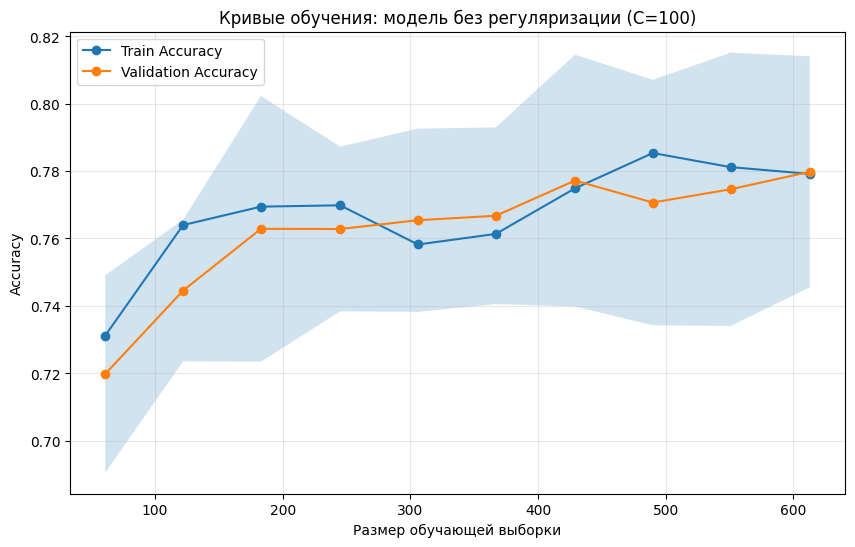

In [ ]:
# Кривые обучения (Learning Curves) показывают, как модель ведет себя
# при разном количестве обучающих данных.
# Если train_score растет, а val_score падает — ПЕРЕОБУЧЕНИЕ.
# Если оба низкие — НЕДООБУЧЕНИЕ.

# Масштабирование КРИТИЧНО для LogisticRegression (градиентные методы)
scaler = StandardScaler()
X_diab_scaled = scaler.fit_transform(X_diab)

# Модель без регуляризации (C=очень большое → почти нет штрафа)
model_overfit = LogisticRegression(C=100, max_iter=1000, random_state=42)

# Строим кривые обучения
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model_overfit,
    X=X_diab_scaled,
    y=y_diab,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Train Accuracy')
plt.plot(train_sizes, np.mean(val_scores, axis=1), 'o-', label='Validation Accuracy')
plt.fill_between(
    train_sizes,
    np.mean(val_scores, axis=1) - np.std(val_scores, axis=1),
    np.mean(val_scores, axis=1) + np.std(val_scores, axis=1),
    alpha=0.2
)
plt.xlabel('Размер обучающей выборки')
plt.ylabel('Accuracy')
plt.title('Кривые обучения: модель без регуляризации (C=100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Вывод: на маленьком датасете переобучение не всегда явно видно,
# но разрыв между train и val указывает на высокую дисперсию модели.

Шаг A3: Сравнение L1 (Lasso) и L2 (Ridge) регуляризации

Lasso обнулил признаков: 1 из 8
Ridge обнулил признаков: 0 из 8


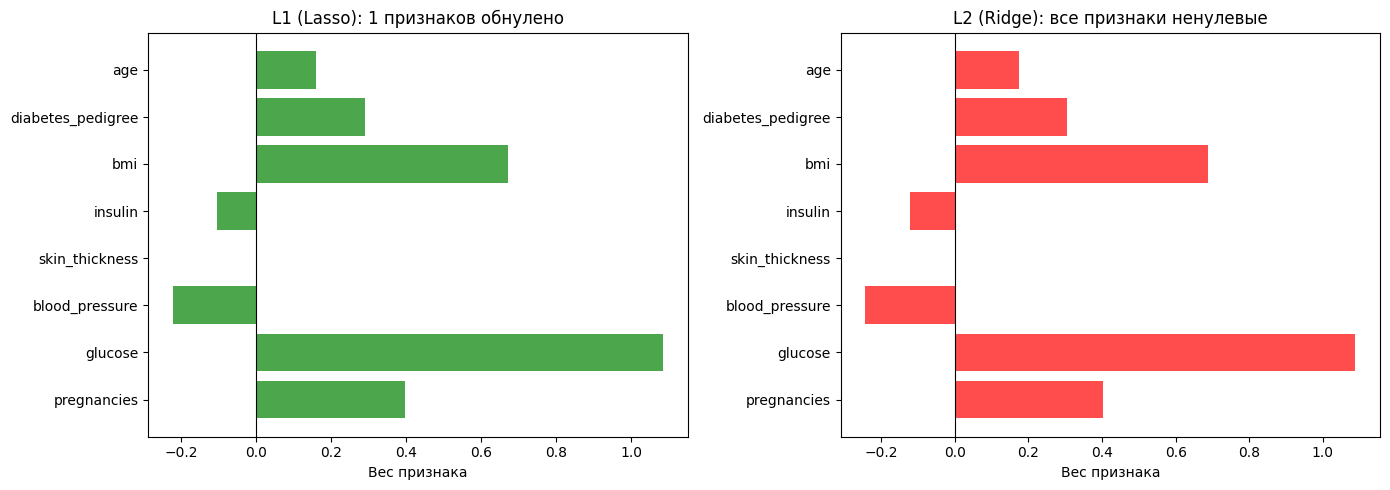

In [ ]:
# В LogisticRegression:
# - penalty='l2' (Ridge) — штрафует за сумму квадратов весов → сглаживает модель
# - penalty='l1' (Lasso) — штрафует за сумму модулей весов → ОБНУЛЯЕТ неважные признаки
# - C — обратная сила регуляризации (маленькое C → сильная регуляризация)

# Для L1 нужен solver='saga' или 'liblinear'
lasso = LogisticRegression(penalty='l1', solver='saga', C=0.5, max_iter=5000, random_state=42)
ridge = LogisticRegression(penalty='l2', solver='lbfgs', C=0.5, max_iter=5000, random_state=42)

pipe_lasso = Pipeline([('scaler', StandardScaler()), ('clf', lasso)])
pipe_ridge = Pipeline([('scaler', StandardScaler()), ('clf', ridge)])

pipe_lasso.fit(X_diab, y_diab)
pipe_ridge.fit(X_diab, y_diab)

# Извлекаем веса модели
lasso_coefs = pipe_lasso.named_steps['clf'].coef_[0]
ridge_coefs = pipe_ridge.named_steps['clf'].coef_[0]
features = X_diab.columns

# Сравниваем: сколько признаков обнулил Lasso?
n_zero_lasso = np.sum(np.abs(lasso_coefs) < 1e-6)
print(f"Lasso обнулил признаков: {n_zero_lasso} из {len(features)}")
print(f"Ridge обнулил признаков: {np.sum(np.abs(ridge_coefs) < 1e-6)} из {len(features)}")

# Визуализация весов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lasso
axes[0].barh(features, lasso_coefs, color='green', alpha=0.7)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(f'L1 (Lasso): {n_zero_lasso} признаков обнулено')
axes[0].set_xlabel('Вес признака')

# Ridge
axes[1].barh(features, ridge_coefs, color='red', alpha=0.7)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('L2 (Ridge): все признаки ненулевые')
axes[1].set_xlabel('Вес признака')

plt.tight_layout()
plt.show()

# Вывод: Lasso выполнил отбор признаков (feature selection),
# Ridge только сгладил веса, но не обнулил ни один признак.

Шаг A4: Подбор гиперпараметров — Grid Search vs Random Search

In [ ]:
# Определяем пространство гиперпараметров
# C — сила регуляризации (меньше = сильнее)
# l1_ratio — для ElasticNet (смесь L1 и L2)
param_grid = {
    'clf__penalty': ['l1', 'l2'],
    'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'clf__class_weight': [None, 'balanced']
}

# Grid Search — перебирает ВСЕ комбинации
# Для 2×5×2 = 20 комбинаций × 5 фолдов = 100 обучений
print("Запуск GridSearchCV (полный перебор)...")
grid_search = GridSearchCV(
    estimator=pipe_lasso,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    refit=True
)
grid_search.fit(X_diab, y_diab)

print(f"\nЛучшие параметры (Grid): {grid_search.best_params_}")
print(f"Лучшая accuracy на CV: {grid_search.best_score_:.4f}")

# Random Search — случайно выбирает n_iter комбинаций
# Полезно, когда пространство параметров большое
param_dist = {
    'clf__penalty': ['l1', 'l2'],
    'clf__C': np.logspace(-3, 2, 50),  # 50 значений от 0.001 до 100
    'clf__class_weight': [None, 'balanced']
}

print("\nЗапуск RandomizedSearchCV (15 случайных комбинаций)...")
random_search = RandomizedSearchCV(
    estimator=pipe_lasso,
    param_distributions=param_dist,
    n_iter=15,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_diab, y_diab)

print(f"\nЛучшие параметры (Random): {random_search.best_params_}")
print(f"Лучшая accuracy на CV: {random_search.best_score_:.4f}")

Запуск GridSearchCV (полный перебор)...

Лучшие параметры (Grid): {'clf__C': 0.1, 'clf__class_weight': None, 'clf__penalty': 'l2'}
Лучшая accuracy на CV: 0.7824

Запуск RandomizedSearchCV (15 случайных комбинаций)...

Лучшие параметры (Random): {'clf__penalty': 'l1', 'clf__class_weight': None, 'clf__C': np.float64(1.8420699693267164)}
Лучшая accuracy на CV: 0.7811


# ЧАСТЬ B: Работа с несбалансированными данными на датасете Fraud
Шаг B1: Загрузка и субсэмплинг данных

In [ ]:
from sklearn.datasets import fetch_openml
import numpy as np
from sklearn.model_selection import train_test_split

print("Загрузка через OpenML (data_id=1597)...")
fraud = fetch_openml(data_id=1597, as_frame=True, parser='pandas')

X_fraud = fraud.data
# Безопасное преобразование target (на случай строковых значений)
y_fraud = pd.to_numeric(fraud.target, errors='coerce')
if y_fraud.isna().any():
    # Если target строковый — маппим
    unique_vals = fraud.target.unique()
    print(f"Уникальные значения target: {unique_vals}")
    mapping = {v: i for i, v in enumerate(sorted(unique_vals))}
    y_fraud = fraud.target.map(mapping).astype(int)
else:
    y_fraud = y_fraud.astype(int)

print(f"Исходный размер: {X_fraud.shape}")
print(f"Дисбаланс: {np.bincount(y_fraud)}")

# Субсэмплинг
np.random.seed(42)
fraud_idx = np.where(y_fraud == 1)[0]
legit_idx = np.where(y_fraud == 0)[0]
sampled_legit = np.random.choice(legit_idx, size=20000, replace=False)
balanced_idx = np.concatenate([fraud_idx, sampled_legit])

X_fraud = X_fraud.iloc[balanced_idx].reset_index(drop=True)
y_fraud = y_fraud.iloc[balanced_idx].reset_index(drop=True)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

print(f"\nTrain: {X_train_f.shape}, дисбаланс: {np.bincount(y_train_f)}")
print(f"Test:  {X_test_f.shape}, дисбаланс: {np.bincount(y_test_f)}")

Загрузка через OpenML (data_id=1597)...
Исходный размер: (284807, 29)
Дисбаланс: [284315    492]

Train: (16393, 29), дисбаланс: [15999   394]
Test:  (4099, 29), дисбаланс: [4001   98]


Шаг B2: Почему Accuracy — плохая метрика

In [ ]:
# Наивный классификатор: всегда предсказывает класс 0 (легальная транзакция)
dummy_acc = np.sum(y_test_f == 0) / len(y_test_f)
print(f"Accuracy наивного классификатора: {dummy_acc:.4f}")
print("→ Модель 'всегда 0' имеет 97.6% accuracy, но бесполезна!")

# Правильные метрики для дисбаланса:
# - PR-AUC (Average Precision) — площадь под Precision-Recall кривой
# - F1-score — гармоническое среднее Precision и Recall
# - ROC-AUC — но он может быть слишком оптимистичен при сильном дисбалансе

Accuracy наивного классификатора: 0.9761
→ Модель 'всегда 0' имеет 97.6% accuracy, но бесполезна!


Шаг B3: Сравнение методов борьбы с дисбалансом

In [ ]:
# Базовая модель для сравнения
base_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)

# === МЕТОД 1: Class Weights (алгоритмический подход) ===
# Модель сама увеличивает штраф за ошибку на миноритарном классе
lr_weighted = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
pipe_weighted = Pipeline([('scaler', StandardScaler()), ('clf', lr_weighted)])
pipe_weighted.fit(X_train_f, y_train_f)
pred_weighted = pipe_weighted.predict_proba(X_test_f)[:, 1]

# === МЕТОД 2: SMOTE (синтетический оверсемплинг) ===
# ВАЖНО: SMOTE применяется ТОЛЬКО на train, внутри Pipeline!
# Иначе будет утечка данных (data leakage)
pipe_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', base_lr)
])
pipe_smote.fit(X_train_f, y_train_f)
pred_smote = pipe_smote.predict_proba(X_test_f)[:, 1]

# === МЕТОД 3: ADASYN (адаптивный оверсемплинг) ===
# Генерирует больше синтетических примеров для "сложных" объектов
pipe_adasyn = ImbPipeline([
    ('scaler', StandardScaler()),
    ('adasyn', ADASYN(random_state=42)),
    ('clf', base_lr)
])
pipe_adasyn.fit(X_train_f, y_train_f)
pred_adasyn = pipe_adasyn.predict_proba(X_test_f)[:, 1]

# === МЕТОД 4: Random Forest с class_weight ===
# Деревья лучше работают с несбалансированными данными "из коробки"
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_f, y_train_f)
pred_rf = rf.predict_proba(X_test_f)[:, 1]

# Сравнение метрик
results = pd.DataFrame({
    'Метод': ['Class Weight (LR)', 'SMOTE', 'ADASYN', 'Random Forest'],
    'PR-AUC': [
        average_precision_score(y_test_f, pred_weighted),
        average_precision_score(y_test_f, pred_smote),
        average_precision_score(y_test_f, pred_adasyn),
        average_precision_score(y_test_f, pred_rf)
    ],
    'F1 (threshold=0.5)': [
        f1_score(y_test_f, pred_weighted > 0.5),
        f1_score(y_test_f, pred_smote > 0.5),
        f1_score(y_test_f, pred_adasyn > 0.5),
        f1_score(y_test_f, pred_rf > 0.5)
    ]
})
print("\n=== Сравнение методов ===")
display(results)


=== Сравнение методов ===


,Метод,PR-AUC,F1 (threshold=0.5)
0,Class Weight (LR),0.912210,0.636364
1,SMOTE,0.913447,0.631944
2,ADASYN,0.912431,0.316865
3,Random Forest,0.907532,0.913043


Шаг B4: Focal Loss

Обучение GradientBoosting с Focal Loss (γ=2.0)...

PR-AUC (GB с Focal Loss, γ=2.0): 0.2112
PR-AUC (GB стандартный):           0.7495


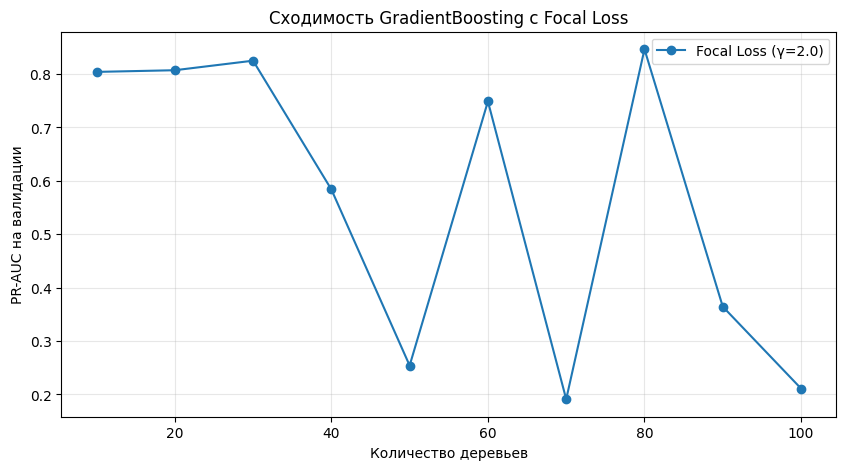

In [ ]:
# Focal Loss (Lin et al., 2017) — модификация BCE, которая уменьшает вес
# "легких" объектов и фокусируется на "сложных".
# Формула: FL(p_t) = -α_t · (1 - p_t)^γ · log(p_t)
# где p_t — вероятность правильного класса, γ — фокусирующий параметр.

# В sklearn нет встроенного Focal Loss, но его можно реализовать через
# итеративное обновление sample_weight в GradientBoosting:
# на каждой итерации мы увеличиваем вес объектов, которые модель
# предсказывает неуверенно (т.е. "сложных").

def focal_loss_sample_weights(y_true, y_proba, gamma=2.0, alpha=0.25):
    """
    Вычисляет веса объектов для Focal Loss.

    Parameters:
    -----------
    y_true : array — истинные метки (0/1)
    y_proba : array — предсказанные вероятности класса 1
    gamma : float — фокусирующий параметр (больше → сильнее фокус на сложных)
    alpha : float — баланс между классами

    Returns:
    --------
    weights : array — веса для каждого объекта
    """
    eps = 1e-7
    # Вероятность правильного класса для каждого объекта
    p_t = np.where(y_true == 1, y_proba, 1 - y_proba)
    p_t = np.clip(p_t, eps, 1 - eps)

    # Балансирующий вес α_t
    alpha_t = np.where(y_true == 1, alpha, 1 - alpha)

    # Focal weight: (1 - p_t)^γ
    focal_weight = (1 - p_t) ** gamma

    # Итоговый вес
    weights = alpha_t * focal_weight
    return weights

# Итеративное обучение GradientBoosting с Focal Loss
# На каждой итерации пересчитываем веса объектов
def train_with_focal_loss(X_train, y_train, X_val, y_val,
                          n_estimators=100, gamma=2.0, learning_rate=0.1):
    """
    Обучает GradientBoosting с Focal Loss через итеративное
    обновление sample_weight.
    """
    # Начальные веса — сбалансированные по классам
    n_pos = np.sum(y_train == 1)
    n_neg = np.sum(y_train == 0)
    sample_weight = np.where(y_train == 1, n_neg / n_pos, 1.0)
    sample_weight = sample_weight / sample_weight.sum() * len(y_train)

    # Инициализируем первую модель
    gb = GradientBoostingClassifier(
        n_estimators=1,
        learning_rate=learning_rate,
        max_depth=4,
        random_state=42
    )
    gb.fit(X_train, y_train, sample_weight=sample_weight)

    # Итеративно добавляем деревья, обновляя веса
    val_scores = []
    for i in range(1, n_estimators):
        # Предсказываем вероятности текущей моделью
        proba = gb.predict_proba(X_train)[:, 1]

        # Пересчитываем веса по Focal Loss
        sample_weight = focal_loss_sample_weights(y_train, proba, gamma=gamma)
        sample_weight = sample_weight / sample_weight.sum() * len(y_train)

        # Дообучаем модель (добавляем еще одно дерево)
        gb.n_estimators = i + 1
        gb.fit(X_train, y_train, sample_weight=sample_weight)

        # Оцениваем на валидации каждые 10 итераций
        if (i + 1) % 10 == 0:
            val_proba = gb.predict_proba(X_val)[:, 1]
            val_scores.append(average_precision_score(y_val, val_proba))

    return gb, val_scores

# Обучаем GradientBoosting с Focal Loss
print("Обучение GradientBoosting с Focal Loss (γ=2.0)...")
gb_focal, val_scores_focal = train_with_focal_loss(
    X_train_f, y_train_f, X_test_f, y_test_f,
    n_estimators=100, gamma=2.0
)
pred_focal = gb_focal.predict_proba(X_test_f)[:, 1]

# Для сравнения — обычный GradientBoosting без Focal Loss
gb_standard = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42
)
gb_standard.fit(X_train_f, y_train_f)
pred_standard = gb_standard.predict_proba(X_test_f)[:, 1]

print(f"\nPR-AUC (GB с Focal Loss, γ=2.0): {average_precision_score(y_test_f, pred_focal):.4f}")
print(f"PR-AUC (GB стандартный):           {average_precision_score(y_test_f, pred_standard):.4f}")

# Визуализация сходимости
plt.figure(figsize=(10, 5))
plt.plot(range(10, 101, 10), val_scores_focal, 'o-', label='Focal Loss (γ=2.0)')
plt.xlabel('Количество деревьев')
plt.ylabel('PR-AUC на валидации')
plt.title('Сходимость GradientBoosting с Focal Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Шаг B5: Пороговая калибровка (Threshold Calibration)

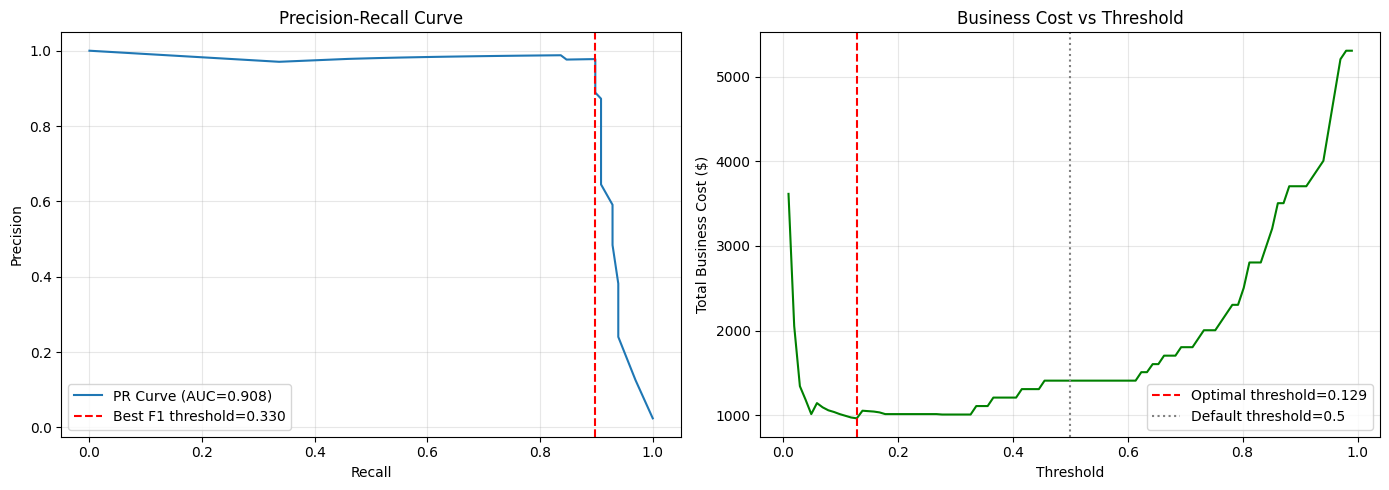


Порог для максимизации F1: 0.330
Порог для минимизации бизнес-потерь: 0.129
Потери при пороге 0.5: $1410
Потери при оптимальном пороге: $965
Экономия: $445 (31.6%)


In [ ]:
# Стандартный порог 0.5 НЕ ОПТИМАЛЕН для несбалансированных данных.
# Найдем порог, максимизирующий F1-score, и порог, минимизирующий бизнес-потери.

# Получаем предсказания лучшей модели (например, Random Forest)
proba = rf.predict_proba(X_test_f)[:, 1]

# Строим Precision-Recall кривую
precisions, recalls, thresholds = precision_recall_curve(y_test_f, proba)

# Ищем порог для максимизации F1
f1_scores_curve = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores_curve)
best_threshold_f1 = thresholds[best_idx]

# Бизнес-задача:
# - FN (пропустить мошенника) стоит $100
# - FP (заблокировать легального клиента) стоит $5
def business_cost(y_true, y_pred, fn_cost=100, fp_cost=5):
    cm = confusion_matrix(y_true, y_pred)
    fn = cm[1, 0]  # False Negative
    fp = cm[0, 1]  # False Positive
    return fn * fn_cost + fp * fp_cost

# Перебираем пороги и считаем бизнес-потери
thresholds_to_test = np.linspace(0.01, 0.99, 100)
costs = []
for thr in thresholds_to_test:
    pred = (proba >= thr).astype(int)
    costs.append(business_cost(y_test_f, pred))

best_idx_cost = np.argmin(costs)
best_threshold_cost = thresholds_to_test[best_idx_cost]

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Левый график: PR-кривая с оптимальным порогом
axes[0].plot(recalls, precisions, label=f'PR Curve (AUC={average_precision_score(y_test_f, proba):.3f})')
axes[0].axvline(recalls[best_idx], color='red', linestyle='--',
                label=f'Best F1 threshold={best_threshold_f1:.3f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Правый график: бизнес-потери
axes[1].plot(thresholds_to_test, costs, 'g-')
axes[1].axvline(best_threshold_cost, color='red', linestyle='--',
                label=f'Optimal threshold={best_threshold_cost:.3f}')
axes[1].axvline(0.5, color='gray', linestyle=':', label='Default threshold=0.5')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Total Business Cost ($)')
axes[1].set_title('Business Cost vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Итоги
cost_default = business_cost(y_test_f, proba >= 0.5)
cost_optimal = costs[best_idx_cost]
print(f"\nПорог для максимизации F1: {best_threshold_f1:.3f}")
print(f"Порог для минимизации бизнес-потерь: {best_threshold_cost:.3f}")
print(f"Потери при пороге 0.5: ${cost_default}")
print(f"Потери при оптимальном пороге: ${cost_optimal}")
print(f"Экономия: ${cost_default - cost_optimal} ({(cost_default - cost_optimal)/cost_default*100:.1f}%)")

# Задания для студентов

## Общие требования

*  Все расчеты выполнять с использованием Stratified K-Fold кросс-валидации.
*  В качестве основной метрики для дисбаланса использовать PR-AUC (Average Precision).
*   Код должен быть снабжен комментариями, объясняющими каждый шаг.
*   Отчет — Jupyter Notebook (.ipynb) с выводами после каждого задания.

# Задание 1. Анализ регуляризации на датасете Diabetes
Цель: Понять, как L1 и L2 регуляризация влияют на веса модели и качество.

Обучите LogisticRegression с penalty='l1' и penalty='l2' на датасете Diabetes.
Подберите параметр C из диапазона [0.001, 0.01, 0.1, 1.0, 10.0] с помощью GridSearchCV (5-fold Stratified CV).

Постройте два графика:

Количество ненулевых весов Lasso в зависимости от C.

Среднее абсолютное значение весов Ridge в зависимости от C.

Вопрос для отчета:

Почему при очень маленьком C (сильная регуляризация) модель недообучается, а при очень большом — переобучается? Приведите конкретные цифры из вашего эксперимента.

Подсказка: Для L1 используйте solver='saga', для L2 — solver='lbfgs'.

# Задание 2. Детекция утечки данных (Data Leakage)

Цель: На практике понять, почему SMOTE нужно применять внутри CV.

Неправильный подход: Примените SMOTE ко всему датасету Fraud (до разделения на train/test), затем разделите и обучите модель. Замерьте PR-AUC на тесте.

Правильный подход: Используйте imblearn.pipeline.Pipeline с SMOTE внутри cross_val_score или GridSearchCV. Замерьте PR-AUC. Сравните результаты.

Вопрос для отчета:

На сколько процентов завышает метрику неправильный подход?

Объясните механизм утечки: что именно "подсматривает" модель при неправильном применении SMOTE?

# Задание 3. Реализация Focal Loss с нуля

Цель: Понять математику Focal Loss.
В коде выше Focal Loss реализован через итеративное обновление sample_weight.

Ваша задача — реализовать альтернативный подход:

Создайте собственный класс FocalLossClassifier, наследуясь от sklearn.base.BaseEstimator и ClassifierMixin.

Внутри реализуйте обучение через SGDClassifier с модификацией: на каждой эпохе пересчитывайте веса объектов по формуле Focal Loss.

Протестируйте ваш классификатор на датасете Fraud с параметрами γ ∈ {0.0, 1.0, 2.0, 5.0}.

Постройте график зависимости PR-AUC от γ.

Вопросы для отчета: При каком γ модель показывает лучшее качество? Почему слишком большое γ может ухудшить результат?

Подсказка:

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

class FocalLossClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, gamma=2.0, alpha=0.25, n_estimators=50):
        self.gamma = gamma
        self.alpha = alpha
        self.n_estimators = n_estimators

    def fit(self, X, y):
        # Ваша реализация
        ...

    def predict_proba(self, X):
        # Ваша реализация
        ...

# Задание 4. Бизнес-ориентированная пороговая калибровка

Цель: Связать ML-метрики с реальными бизнес-показателями.

Дана новая матрица стоимостей ошибок для задачи обнаружения мошенничества:

FN (пропустить мошенника): $250 (прямой убыток)

FP (заблокировать легального клиента): $15 (репутационные потери + звонок в поддержку)

TP (поймать мошенника): +$50 (бонус за предотвращение)

TN: $0

Напишите функцию profit(y_true, y_pred, costs_dict), которая считает общую прибыль (а не убыток).

Для модели Random Forest из кода выше найдите порог, максимизирующий прибыль на тестовой выборке.

Постройте график зависимости прибыли от порога.

Сравните прибыль при пороге 0.5 и при оптимальном пороге.

Вопросы для отчета: Почему оптимальный порог для максимизации прибыли отличается от порога, максимизирующего F1? В каких бизнес-сценариях это важно?

# Задание 5 (бонусное). Сравнение Stratified K-Fold и обычного K-Fold
Цель: Понять важность стратификации.

Обучите LogisticRegression на датасете Fraud с обычным KFold(n_splits=5) и с стратифицированным StratifiedKFold(n_splits=5).

Для каждого фолда посчитайте долю класса 1 в train и в validation.

Постройте график: доля миноритарного класса в validation-фолдах для обоих методов.

Вопросы для отчета: В каких фолдах обычного K-Fold может вообще не оказаться класса 1? Как это влияет на оценку модели?

# Рекомендации по выполнению
Начинайте с малого: сначала проверьте код на маленькой подвыборке, потом запускайте на полных данных.

Фиксируйте random_state во всех случайных процессах — это обеспечит воспроизводимость.

Сохраняйте промежуточные результаты в pandas DataFrame — так проще строить итоговые таблицы.

Читайте документацию sklearn (?GridSearchCV в Jupyter) — там много полезных примеров.

Для Focal Loss (Задание 3) не бойтесь ошибаться — это сложная тема, главное — понимание математики.